# Análisis descriptivo de tickets · Swiss Life

**Notebook de Python para Jupyter.** Analiza el JSON completo: estructura, calidad,
distribuciones, fechas, tiempos hasta el cierre, asignaciones y textos. Los resultados
incluidos se calcularon sobre los **20.000 registros** del archivo adjunto; no se usa una muestra.

### Cómo ejecutarlo en tu Mac

1. Guarda este notebook y `jira_first_20000_requested_fields_synthetic.json` en la misma carpeta.
2. Abre una terminal en esa carpeta y ejecuta los comandos de abajo. Python es independiente
   de Node/npm; si `python3 --version` no funciona, instala Python primero.
3. Abre el notebook en JupyterLab y selecciona **Run → Run All Cells**. También puedes abrirlo
   en VS Code con las extensiones Python y Jupyter y elegir el entorno `.venv`.
4. Si el JSON está en otra carpeta, cambia `DATA_FILE` en la primera celda de código.

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install jupyterlab pandas numpy matplotlib seaborn
python -m jupyterlab
```

Las tablas completas se exportan a `resultados_tickets/`, junto con los gráficos PNG.
Mostrar los 10 primeros valores en una tabla **no recorta los datos utilizados** en los cálculos.
Puedes volver a ejecutar todas las celdas: se actualizan los archivos generados, sin modificar el JSON.

### Antes de interpretar los resultados

El `README.md` adjunto indica que los datos son **sintéticos** y que **Priority, Urgency e
Impact se muestrearon de forma aleatoria e independiente del contenido**. Sus frecuencias
describen el generador de datos, no la gravedad real del negocio. Los servicios pueden estar
mal etiquetados o ser genéricos y algunos comentarios de cierre son poco informativos.

Este notebook hace análisis descriptivo; **no entrena ni reentrena un modelo**. No calcula
precisión de clasificación ni evalúa el reto de 20 tickets nuevos, cuyo archivo no se ha adjuntado.

## 1. Configuración

`DATA_FILE` es la ubicación de entrada. `OUTPUT_DIR` es la carpeta de resultados.
La exportación detallada de tickets y comentarios es opcional; las tablas de resumen se guardan por defecto.

In [8]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.metadata
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

DATA_FILE = Path("jira_first_20000_requested_fields_synthetic.json")
OUTPUT_DIR = Path("resultados_tickets")
EXPORTAR = True
EXPORTAR_DATOS_DETALLADOS = False
TOP_N = 10

# Algunos entornos añaden '01-' al nombre del archivo adjunto.
if not DATA_FILE.is_file() and DATA_FILE.name == "jira_first_20000_requested_fields_synthetic.json":
    candidatos = [
        Path("01-jira_first_20000_requested_fields_synthetic.json"),
        Path("upload") / DATA_FILE.name,
        Path("upload/01-jira_first_20000_requested_fields_synthetic.json"),
        Path("data") / DATA_FILE.name,
    ]
    DATA_FILE = next((p for p in candidatos if p.is_file()), DATA_FILE)

if not DATA_FILE.is_file():
    raise FileNotFoundError(
        "No se encuentra el JSON. Colócalo junto al notebook o cambia DATA_FILE por su ruta."
    )

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
AZUL, VERDE, NARANJA = "#2364AA", "#27856B", "#D88728"
tablas = {}  # Aquí guardamos tablas completas, incluso si solo mostramos sus primeras filas.

def mostrar_tabla(nombre, tabla, limite=None):
    tablas[nombre] = tabla.copy()
    display(tabla if limite is None else tabla.head(limite))

def mostrar_figura(nombre, fig):
    fig.tight_layout()
    if EXPORTAR:
        (OUTPUT_DIR / "graficos").mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / "graficos" / f"{nombre}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def texto_corto(valor, longitud=140):
    texto = json.dumps(valor, ensure_ascii=False) if isinstance(valor, (list, dict)) else str(valor)
    return texto if len(texto) <= longitud else texto[:longitud - 1] + "…"

versiones = {p: importlib.metadata.version(p) for p in ["pandas", "numpy", "matplotlib", "seaborn"]}
print("Archivo:", DATA_FILE.name)
print("Python:", platform.python_version(), "| Paquetes:", versiones)

Archivo: jira_first_20000_requested_fields_synthetic.json
Python: 3.9.6 | Paquetes: {'pandas': '2.3.3', 'numpy': '2.0.2', 'matplotlib': '3.9.4', 'seaborn': '0.13.2'}


## 2. Cargar todos los registros y comprobar el esquema

El archivo real es una lista JSON de objetos, con **16 campos por ticket**. No contiene
`Issue ID`, `Issue Key`, `Request type`, `Severity`, `Due date` ni `Linked issues`.
Por eso generamos después un identificador de fila local: **no es una clave de Jira**.
La tabla original se conserva en `raw`; no se rellenan vacíos con valores inventados.

In [9]:
contenido = DATA_FILE.read_bytes()
sha256_entrada = hashlib.sha256(contenido).hexdigest()
registros = json.loads(contenido.decode("utf-8-sig"))
if not isinstance(registros, list) or not registros or not all(isinstance(r, dict) for r in registros):
    raise ValueError("Se esperaba una lista JSON no vacía de objetos de ticket.")

CAMPOS = [
    "Work type", "Summary", "Description", "Affected Business or IT Services",
    "Business Entity", "Service Team(s)", "Reporter", "Assignee", "Priority",
    "Urgency", "Impact", "Created date", "Status", "Resolution", "Resolution date", "All Comments",
]
CAMPOS_LISTA = ["Affected Business or IT Services", "Business Entity", "Service Team(s)", "All Comments"]
raw = pd.DataFrame(registros)
faltan_columnas = sorted(set(CAMPOS) - set(raw.columns))
if faltan_columnas:
    raise ValueError(f"Faltan columnas esperadas: {faltan_columnas}. Revisa el esquema antes de continuar.")

N = len(raw)
print(f"Tickets leídos: {N:,} | Campos: {raw.shape[1]} | Tamaño: {len(contenido) / 1024**2:.2f} MiB")
print("SHA-256 de entrada:", sha256_entrada)
print("Campos adicionales:", sorted(set(raw.columns) - set(CAMPOS)))
display(raw.head(3))

Tickets leídos: 20,000 | Campos: 16 | Tamaño: 23.81 MiB
SHA-256 de entrada: 6f3ad42cbe5095d6541c47095258c233554c1da46fbc47c529735667876f8844
Campos adicionales: []


,Work type,Summary,Description,Affected Business or IT Services,Business Entity,Service Team(s),Reporter,Assignee,Priority,Urgency,Impact,Created date,Status,Resolution,Resolution date,All Comments
0,Service Request,New license requested for Tax Reporting,A new user requires a license for Tax Reporting to support an operational activity. The request ...,[Tax Reporting],[Nordics],[Tax & Reporting],luca.rinaldi@intcom.com,oliver.varga@intcom.com,low,low,low,2026-03-03 19:36,done,done,2026-03-16 11:51,[nina.baker@intcom.com: Initial triage assigned to Tax & Reporting and reviewed against the serv...
1,Service Request,New license requested for Outlook & Email,A new user requires a license for Outlook & Email to support an operational activity. The reques...,[Outlook & Email],[Switzerland],[Enterprise Applications],maia.berg@intcom.com,jack.martin@intcom.com,low,medium,lowest,2026-06-07 07:38,done,cannot reproduce,2026-06-09 13:30,[louis.belov@intcom.com: Initial triage assigned to Enterprise Applications and reviewed against...
2,Service Request,Incorrect incident title for service request in Portfolio Accounting,"The submitted title suggests an incident affecting Portfolio Accounting, but the actual request ...",[Portfolio Accounting],[Switzerland],[Investment Operations],info@extcom_19.com,tania.gupta@intcom.com,lowest,low,medium,2026-06-23 14:00,done,clarification,2026-06-28 09:07,[marta.marchand@intcom.com: Initial triage assigned to Investment Operations and reviewed agains...


## 3. Diccionario de los campos y ejemplos reales

`Status` indica el estado del proceso. `Resolution` indica el resultado del cierre:
un estado `done` puede tener resolución `cancelled` o `cannot reproduce`.
**Una resolución `done` tampoco demuestra, por sí sola, que el usuario validó la solución.**

In [10]:
definiciones = {
    "Work type": ("Tipo de trabajo: Incident o Service Request.", "Clasificación inicial que el agente puede proponer."),
    "Summary": ("Título breve del ticket.", "Entrada textual; se complementa con Description."),
    "Description": ("Explicación del problema o de la petición.", "Entrada principal para clasificar y recuperar casos similares."),
    "Affected Business or IT Services": ("Lista de servicios declarados como afectados.", "Se relaciona con equipo y criticidad; puede estar mal etiquetada."),
    "Business Entity": ("Lista de entidades o regiones afectadas.", "Da contexto geográfico; no equivale a impacto o urgencia."),
    "Service Team(s)": ("Lista de equipos a los que se asignó el ticket.", "Histórico de enrutamiento; no garantiza la asignación correcta."),
    "Reporter": ("Persona o dirección que comunicó la petición.", "Permite describir el origen; no es necesariamente la persona afectada."),
    "Assignee": ("Persona responsable asignada al ticket.", "Se relaciona con el equipo; contar tickets no mide productividad."),
    "Priority": ("Prioridad registrada del ticket.", "En este dataset es aleatoria: no usar como etiqueta de gravedad válida."),
    "Urgency": ("Urgencia registrada: cuánta demora se toleraría.", "En este dataset es aleatoria y no se deduce del texto."),
    "Impact": ("Impacto registrado: alcance de las consecuencias.", "En este dataset es aleatorio; no confundir con criticidad del servicio."),
    "Created date": ("Fecha y hora de creación.", "Inicio del intervalo hasta el cierre; el archivo no indica zona horaria."),
    "Status": ("Estado actual observado: open, in progress o done.", "Permite separar tickets abiertos de cerrados en esta instantánea."),
    "Resolution": ("Resultado de cierre: done, cancelled, clarification o cannot reproduce.", "Se analiza junto con Status y Resolution date; no contiene una solución detallada."),
    "Resolution date": ("Fecha y hora de cierre o resolución registrada.", "Con Created date permite medir tiempo natural transcurrido."),
    "All Comments": ("Lista de comentarios, normalmente con el autor como prefijo.", "Puede contener pasos de solución, respuestas genéricas o información posterior al ingreso."),
}
filas_diccionario = []
for campo in CAMPOS:
    ejemplos = list(dict.fromkeys(json.dumps(r.get(campo), ensure_ascii=False) for r in registros))[:3]
    significado, relacion = definiciones[campo]
    fila = {"campo": campo, "significado": significado, "relacion_con_el_agente": relacion}
    for i in range(3):
        fila[f"ejemplo_{i + 1}"] = texto_corto(json.loads(ejemplos[i]), 95) if i < len(ejemplos) else "No hay otro valor distinto"
    filas_diccionario.append(fila)
diccionario = pd.DataFrame(filas_diccionario)
mostrar_tabla("diccionario_campos", diccionario[["campo", "significado", "relacion_con_el_agente"]])
mostrar_tabla("ejemplos_campos", diccionario[["campo", "ejemplo_1", "ejemplo_2", "ejemplo_3"]])

,campo,significado,relacion_con_el_agente
0,Work type,Tipo de trabajo: Incident o Service Request.,Clasificación inicial que el agente puede proponer.
1,Summary,Título breve del ticket.,Entrada textual; se complementa con Description.
2,Description,Explicación del problema o de la petición.,Entrada principal para clasificar y recuperar casos similares.
3,Affected Business or IT Services,Lista de servicios declarados como afectados.,Se relaciona con equipo y criticidad; puede estar mal etiquetada.
4,Business Entity,Lista de entidades o regiones afectadas.,Da contexto geográfico; no equivale a impacto o urgencia.
5,Service Team(s),Lista de equipos a los que se asignó el ticket.,Histórico de enrutamiento; no garantiza la asignación correcta.
6,Reporter,Persona o dirección que comunicó la petición.,Permite describir el origen; no es necesariamente la persona afectada.
7,Assignee,Persona responsable asignada al ticket.,Se relaciona con el equipo; contar tickets no mide productividad.
8,Priority,Prioridad registrada del ticket.,En este dataset es aleatoria: no usar como etiqueta de gravedad válida.
9,Urgency,Urgencia registrada: cuánta demora se toleraría.,En este dataset es aleatoria y no se deduce del texto.


,campo,ejemplo_1,ejemplo_2,ejemplo_3
0,Work type,Service Request,Incident,No hay otro valor distinto
1,Summary,New license requested for Tax Reporting,New license requested for Outlook & Email,Incorrect incident title for service request in Portfolio Accounting
2,Description,A new user requires a license for Tax Reporting to support an operational activity. The reques…,A new user requires a license for Outlook & Email to support an operational activity. The requ…,"The submitted title suggests an incident affecting Portfolio Accounting, but the actual reques…"
3,Affected Business or IT Services,"[""Tax Reporting""]","[""Outlook & Email""]","[""Portfolio Accounting""]"
4,Business Entity,"[""Nordics""]","[""Switzerland""]","[""Germany""]"
5,Service Team(s),"[""Tax & Reporting""]","[""Enterprise Applications""]","[""Investment Operations""]"
6,Reporter,luca.rinaldi@intcom.com,maia.berg@intcom.com,info@extcom_19.com
7,Assignee,oliver.varga@intcom.com,jack.martin@intcom.com,tania.gupta@intcom.com
8,Priority,low,lowest,medium
9,Urgency,low,medium,lowest


## 4. Completitud y tipos de datos

Se distinguen una clave ausente, `null`, texto vacío y lista vacía. El porcentaje de
completitud usa **todos los tickets como denominador** y no garantiza que el valor sea correcto.
Un campo de resolución vacío en un ticket abierto puede ser perfectamente esperable.

,campo,tipos,claves_ausentes,null,texto_vacio,contenedor_vacio,informados,pct_completitud,valores_distintos_incluye_null
0,Work type,str,0,0,0,0,20000,100.00,2
1,Summary,str,0,0,0,0,20000,100.00,173
2,Description,str,0,0,0,0,20000,100.00,173
3,Affected Business or IT Services,list,0,0,0,0,20000,100.00,20
4,Business Entity,list,0,0,0,0,20000,100.00,5
5,Service Team(s),list,0,0,0,0,20000,100.00,11
6,Reporter,str,0,0,0,0,20000,100.00,92
7,Assignee,str,0,0,0,0,20000,100.00,30
8,Priority,str,0,0,0,0,20000,100.00,5
9,Urgency,str,0,0,0,0,20000,100.00,5


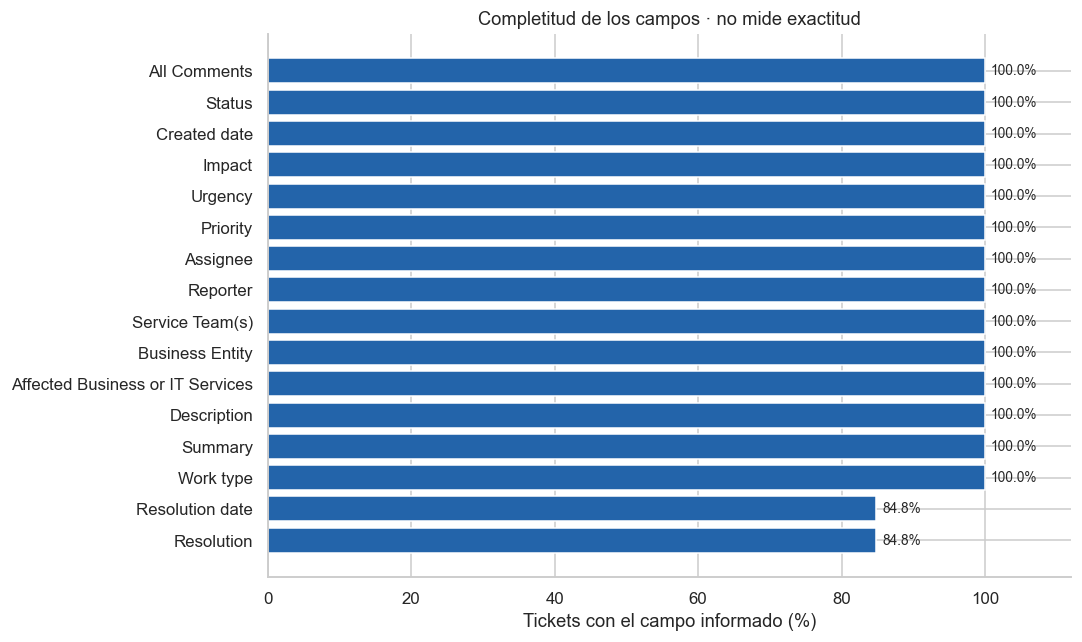

In [11]:
def clase_celda(registro, campo):
    if campo not in registro:
        return "clave_ausente"
    valor = registro[campo]
    if valor is None:
        return "null"
    if isinstance(valor, str) and not valor.strip():
        return "texto_vacio"
    if isinstance(valor, (list, dict)) and not valor:
        return "contenedor_vacio"
    return "informado"

perfil_filas = []
for campo in raw.columns:
    estados = pd.Series([clase_celda(r, campo) for r in registros]).value_counts()
    valores_distintos = len({json.dumps(r[campo], sort_keys=True, ensure_ascii=False) for r in registros if campo in r})
    perfil_filas.append({
        "campo": campo,
        "tipos": ", ".join(sorted({type(r[campo]).__name__ for r in registros if campo in r})),
        "claves_ausentes": int(estados.get("clave_ausente", 0)),
        "null": int(estados.get("null", 0)),
        "texto_vacio": int(estados.get("texto_vacio", 0)),
        "contenedor_vacio": int(estados.get("contenedor_vacio", 0)),
        "informados": int(estados.get("informado", 0)),
        "pct_completitud": 100 * estados.get("informado", 0) / N,
        "valores_distintos_incluye_null": valores_distintos,
    })
perfil = pd.DataFrame(perfil_filas)
mostrar_tabla("calidad_campos", perfil)

fig, ax = plt.subplots(figsize=(10, 6))
p = perfil.sort_values("pct_completitud", ascending=True)
ax.barh(p["campo"], p["pct_completitud"], color=AZUL)
ax.set(xlim=(0, 112), xlabel="Tickets con el campo informado (%)", title="Completitud de los campos · no mide exactitud")
for i, v in enumerate(p["pct_completitud"]):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9)
mostrar_figura("01_completitud", fig)

## 5. Preparar una tabla por ticket y tablas separadas para las listas

Las listas de servicios, entidades, equipos y comentarios se mantienen separadas.
Expandirlas todas a la vez podría multiplicar filas y falsear los recuentos.
`analysis_row_id` identifica una fila del archivo en su orden original; cambia si se reordena el JSON.

Las fechas del archivo no incluyen zona horaria. Se interpretan como fechas locales **sin
asignarles una zona inventada**, con el formato `AAAA-MM-DD HH:MM`. Los intervalos son de
tiempo natural, no horas laborales, esfuerzo del analista ni cumplimiento de SLA.

In [12]:
df = raw.copy(deep=True)
df.insert(0, "analysis_row_id", np.arange(1, N + 1))

# La normalización solo afecta a la copia de trabajo. No se cambia el contenido del JSON.
for campo in set(CAMPOS) - set(CAMPOS_LISTA):
    df[campo] = df[campo].astype("string").str.strip().replace("", pd.NA)
for campo in ["Status", "Resolution", "Priority", "Urgency", "Impact"]:
    df[campo] = df[campo].str.casefold()

for campo in CAMPOS_LISTA:
    mal_formadas = raw[campo].map(
        lambda v: not (v is None or isinstance(v, list) and all(isinstance(x, str) for x in v))
    )
    if mal_formadas.any():
        raise ValueError(f"{campo}: se esperaban listas de texto; revisa las filas con otro tipo.")
    df[campo] = raw[campo].map(
        lambda v: [x.strip() for x in v if x.strip()] if isinstance(v, list) else []
    )

df["created_at"] = pd.to_datetime(df["Created date"], format="%Y-%m-%d %H:%M", errors="coerce")
df["resolved_at"] = pd.to_datetime(df["Resolution date"], format="%Y-%m-%d %H:%M", errors="coerce")
df["cerrado"] = df["Status"].eq("done").fillna(False)
df["n_comments"] = df["All Comments"].map(len)
df["dias_hasta_cierre"] = (df["resolved_at"] - df["created_at"]).dt.total_seconds() / 86400

def relacion(campo):
    salida = df[["analysis_row_id", campo]].explode(campo).dropna(subset=[campo])
    return salida.drop_duplicates(["analysis_row_id", campo]).reset_index(drop=True)

servicios = relacion("Affected Business or IT Services")
entidades = relacion("Business Entity")
equipos = relacion("Service Team(s)")

estructura_listas = pd.DataFrame([
    {"campo": campo, "min_elementos": df[campo].map(len).min(),
     "max_elementos": df[campo].map(len).max(), "tickets_con_varios": int(df[campo].map(len).gt(1).sum()),
     "total_elementos": df[campo].map(len).sum()}
    for campo in CAMPOS_LISTA
])
mostrar_tabla("estructura_listas", estructura_listas)

,campo,min_elementos,max_elementos,tickets_con_varios,total_elementos
0,Affected Business or IT Services,1,1,0,20000
1,Business Entity,1,1,0,20000
2,Service Team(s),1,1,0,20000
3,All Comments,1,5,15885,52845


## 6. Volumen, tipo de trabajo y estado

Estas proporciones describen la instantánea del archivo. No son tasas de éxito del agente.
Los porcentajes de cada columna se calculan sobre los 20.000 tickets, incluyendo valores
vacíos si los hubiera.

,metrica,valor
0,Tickets,20000
1,Campos originales,16
2,Cerrados: Status = done,16969
3,Abiertos o en curso,3031
4,Resolución registrada = done,4236
5,Servicios declarados distintos,20
6,Entidades distintas,5
7,Equipos distintos,11
8,Responsables distintos,30
9,Reportantes distintos,92


,valor,tickets,pct_tickets
0,Incident,16000,80.00
1,Service Request,4000,20.00


,valor,tickets,pct_tickets
0,open,967,4.83
1,in progress,2064,10.32
2,done,16969,84.84


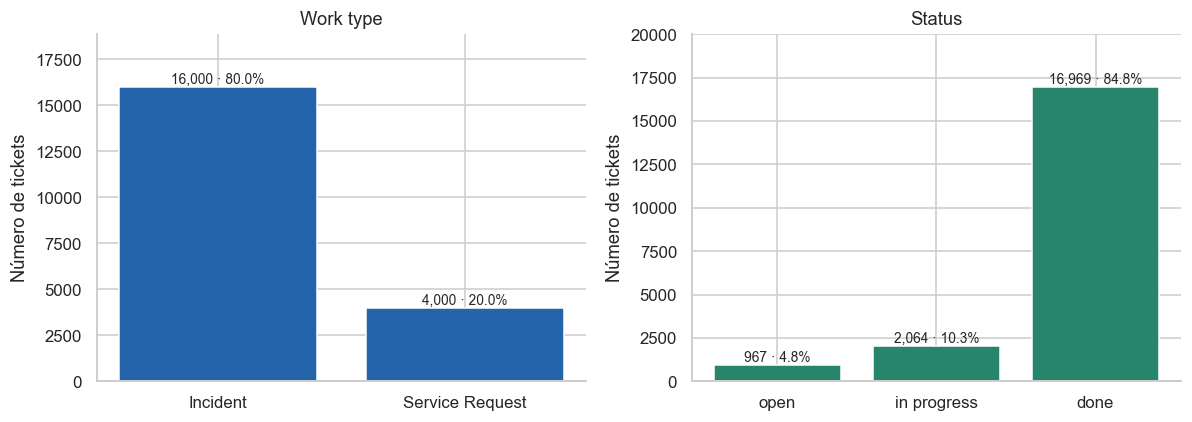

In [13]:
def frecuencia(serie, orden=None, denominador=None):
    conteos = serie.astype("string").fillna("(sin dato)").value_counts()
    if orden is not None:
        resto = [v for v in conteos.index if v not in orden]
        conteos = conteos.reindex(list(orden) + resto, fill_value=0)
    denom = len(serie) if denominador is None else denominador
    return pd.DataFrame({"valor": conteos.index, "tickets": conteos.values,
                         "pct_tickets": 100 * conteos.values / denom if denom else np.nan})

resumen_general = pd.DataFrame([
    ("Tickets", N), ("Campos originales", len(raw.columns)),
    ("Cerrados: Status = done", int(df["cerrado"].sum())),
    ("Abiertos o en curso", int(df["Status"].isin(["open", "in progress"]).sum())),
    ("Resolución registrada = done", int(df["Resolution"].eq("done").sum())),
    ("Servicios declarados distintos", servicios.iloc[:, 1].nunique()),
    ("Entidades distintas", entidades.iloc[:, 1].nunique()),
    ("Equipos distintos", equipos.iloc[:, 1].nunique()),
    ("Responsables distintos", df["Assignee"].nunique()),
    ("Reportantes distintos", df["Reporter"].nunique()),
    ("Comentarios", int(df["n_comments"].sum())),
], columns=["metrica", "valor"])
mostrar_tabla("resumen_general", resumen_general)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, campo, orden in zip(axes, ["Work type", "Status"], [None, ["open", "in progress", "done"]]):
    tabla = frecuencia(df[campo], orden)
    mostrar_tabla("frecuencia_" + campo.lower().replace(" ", "_"), tabla)
    ax.bar(tabla["valor"], tabla["tickets"], color=AZUL if campo == "Work type" else VERDE)
    ax.set(title=campo, ylabel="Número de tickets")
    ax.margins(y=0.18)
    for i, r in tabla.iterrows():
        ax.text(i, r["tickets"], f'{r["tickets"]:,} · {r["pct_tickets"]:.1f}%', ha="center", va="bottom", fontsize=9)
mostrar_figura("02_tipo_y_estado", fig)

## 7. Servicios, entidades y criticidad del catálogo

Cada tabla cuenta una vez cada pareja **ticket–categoría**. Si un ticket tuviera varios
servicios, podría aparecer en varias categorías y los porcentajes sumarían más del 100%.
En este archivo cada ticket tiene un solo servicio, una entidad y un equipo.

La criticidad siguiente viene de la lista del README. Se aplica al **servicio declarado**,
que puede estar mal etiquetado. No valida el servicio realmente afectado, ni sustituye
urgencia, impacto o prioridad. `Emailed Support Tickets` merece revisión como etiqueta genérica.

,valor,tickets,pct_tickets
0,Emailed Support Tickets,5423,27.11
1,Outlook & Email,805,4.03
2,Trade Matching,801,4.00
3,Trading Platform,800,4.00
4,Fund Pricing,799,4.00
5,SimCorp Dimension,797,3.98
6,Corporate Actions,780,3.90
7,Securities Settlement,778,3.89
8,Risk & Compliance Monitoring,777,3.88
9,Portfolio Accounting,774,3.87


,valor,tickets,pct_tickets
0,Luxembourg,4113,20.57
1,Nordics,4015,20.07
2,Switzerland,3976,19.88
3,Germany,3965,19.82
4,France,3931,19.66


,valor,tickets,pct_tickets
0,Algún servicio declarado crítico,10759,53.80
1,Solo servicios declarados no críticos,9241,46.20


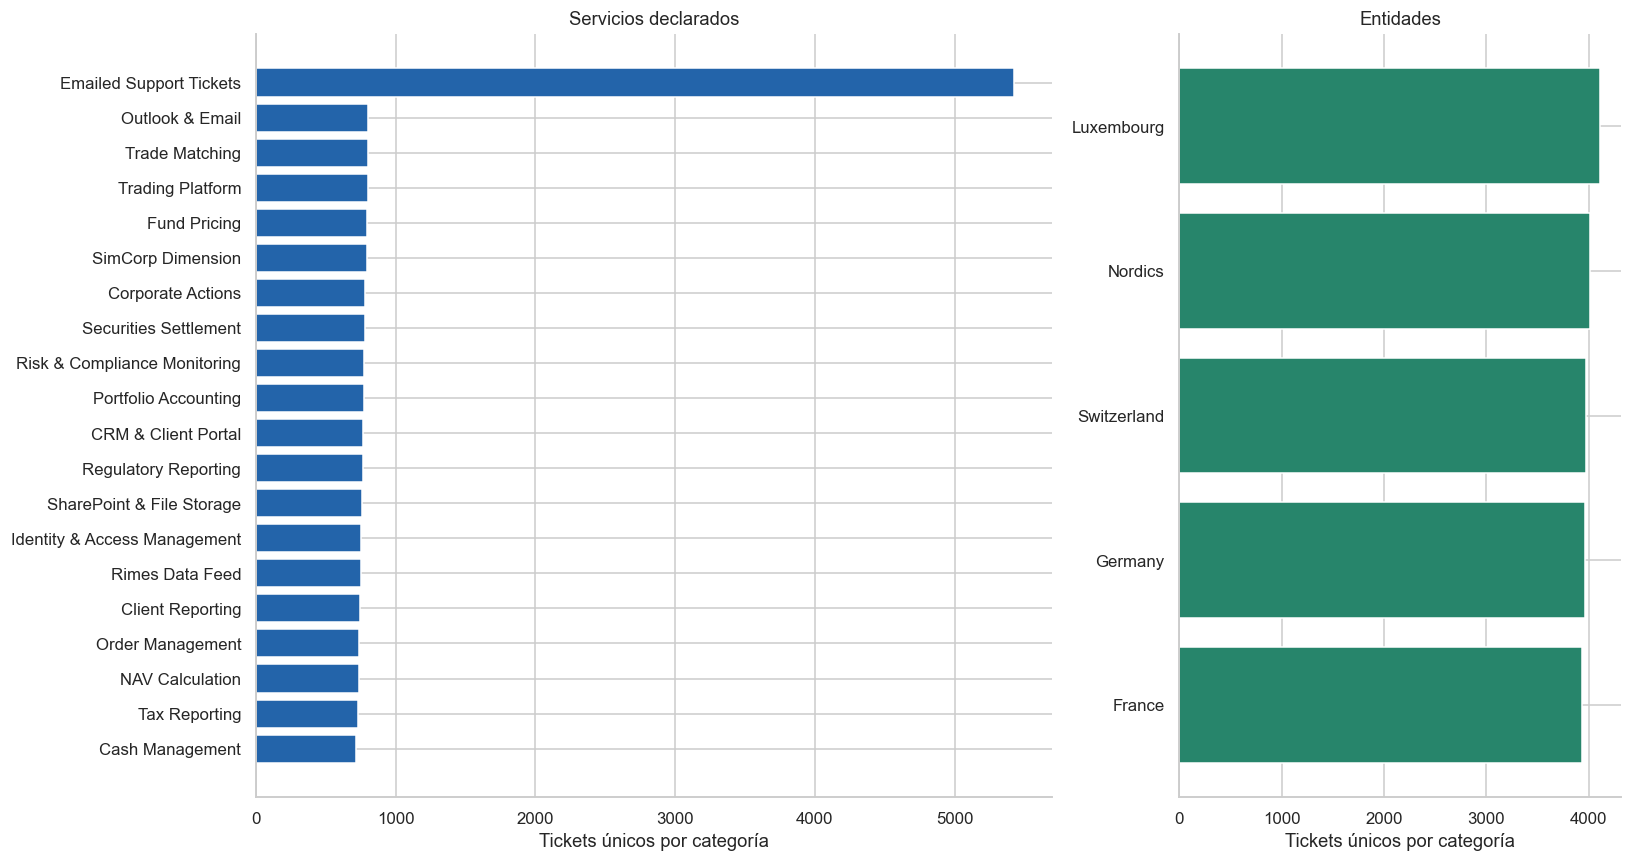

In [14]:
CRITICOS = {
    "Trading Platform", "Order Management", "Trade Matching", "Securities Settlement",
    "Corporate Actions", "Fund Pricing", "NAV Calculation", "Portfolio Accounting",
    "Cash Management", "Risk & Compliance Monitoring", "Regulatory Reporting",
    "SimCorp Dimension", "Rimes Data Feed", "Client Reporting",
}
NO_CRITICOS = {
    "Tax Reporting", "CRM & Client Portal", "Identity & Access Management",
    "SharePoint & File Storage", "Outlook & Email", "Emailed Support Tickets",
}
CATALOGO = sorted(CRITICOS | NO_CRITICOS)

freq_servicios = frecuencia(servicios.iloc[:, 1], denominador=N)
freq_entidades = frecuencia(entidades.iloc[:, 1], denominador=N)
mostrar_tabla("frecuencia_servicios", freq_servicios)
mostrar_tabla("frecuencia_entidades", freq_entidades)

def criticidad(lista):
    if not lista:
        return "Sin servicio declarado"
    if any(s not in CRITICOS | NO_CRITICOS for s in lista):
        return "Algún servicio fuera del catálogo"
    return "Algún servicio declarado crítico" if any(s in CRITICOS for s in lista) else "Solo servicios declarados no críticos"

df["criticidad_catalogo_declarada"] = df["Affected Business or IT Services"].map(criticidad)
mostrar_tabla("criticidad_catalogo_declarada", frecuencia(df["criticidad_catalogo_declarada"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.8, 1]})
for ax, tabla, titulo in [(axes[0], freq_servicios, "Servicios declarados"), (axes[1], freq_entidades, "Entidades")]:
    ordenada = tabla.iloc[::-1]
    ax.barh(ordenada["valor"], ordenada["tickets"], color=AZUL if ax is axes[0] else VERDE)
    ax.set(title=titulo, xlabel="Tickets únicos por categoría")
mostrar_figura("03_servicios_y_entidades", fig)

## 8. Equipos, responsables, reportantes y rutas observadas

Los volúmenes de asignación no miden carga simultánea, dedicación, disponibilidad ni productividad.
La ruta más frecuente es una **asignación observada**, no una recomendación validada.
Para relacionar servicio con equipo o entidad usamos solo tickets con exactamente un valor
en ambos campos: así evitamos inventar correspondencias cuando hay listas múltiples.

,valor,tickets,pct_tickets
0,Service Desk,5423,27.11
1,Enterprise Applications,3116,15.58
2,Investment Operations,2375,11.88
3,Securities Operations,1558,7.79
4,Risk & Controls,1541,7.71
5,Valuation & Pricing,1536,7.68
6,Client Services,1514,7.57
7,Market Data Services,751,3.75
8,Trading Support,739,3.69
9,Tax & Reporting,731,3.65


Assignee: se muestran los 10 valores más frecuentes; la exportación contiene todos.


,valor,tickets,pct_tickets
0,maya.kerr@intcom.com,718,3.59
1,henry.patel@intcom.com,712,3.56
2,nora.leclerc@intcom.com,709,3.54
3,vicky.chen@intcom.com,709,3.54
4,leo.zimmer@intcom.com,703,3.52
5,gina.muller@intcom.com,691,3.46
6,adam.paul@intcom.com,689,3.44
7,zoe.peters@intcom.com,685,3.42
8,tania.gupta@intcom.com,683,3.42
9,david.kim@intcom.com,681,3.40


Reporter: se muestran los 10 valores más frecuentes; la exportación contiene todos.


,valor,tickets,pct_tickets
0,sa_accounting@intcom.com,3512,17.56
1,sa_securities@intcom.com,3401,17.00
2,info@extcom_05.com,231,1.16
3,info@extcom_12.com,228,1.14
4,info@extcom_28.com,220,1.10
5,info@extcom_16.com,214,1.07
6,info@extcom_08.com,212,1.06
7,info@extcom_18.com,208,1.04
8,info@extcom_14.com,206,1.03
9,info@extcom_25.com,204,1.02


,valor,tickets,pct_tickets
0,intcom.com,14033,70.17
1,extcom_05.com,231,1.16
2,extcom_12.com,228,1.14
3,extcom_28.com,220,1.10
4,extcom_16.com,214,1.07
5,extcom_08.com,212,1.06
6,extcom_18.com,208,1.04
7,extcom_14.com,206,1.03
8,extcom_30.com,204,1.02
9,extcom_25.com,204,1.02


Cobertura de rutas con un servicio y un equipo: 20,000/20,000 tickets.


,servicio,equipo,tickets,pct_del_servicio
0,CRM & Client Portal,Client Services,768,100.00
1,Cash Management,Treasury & Cash,716,100.00
2,Client Reporting,Client Services,746,100.00
3,Corporate Actions,Securities Operations,780,100.00
4,Emailed Support Tickets,Service Desk,5423,100.00
5,Fund Pricing,Valuation & Pricing,799,100.00
6,Identity & Access Management,Enterprise Applications,755,100.00
7,NAV Calculation,Valuation & Pricing,737,100.00
8,Order Management,Trading Support,739,100.00
9,Outlook & Email,Enterprise Applications,805,100.00


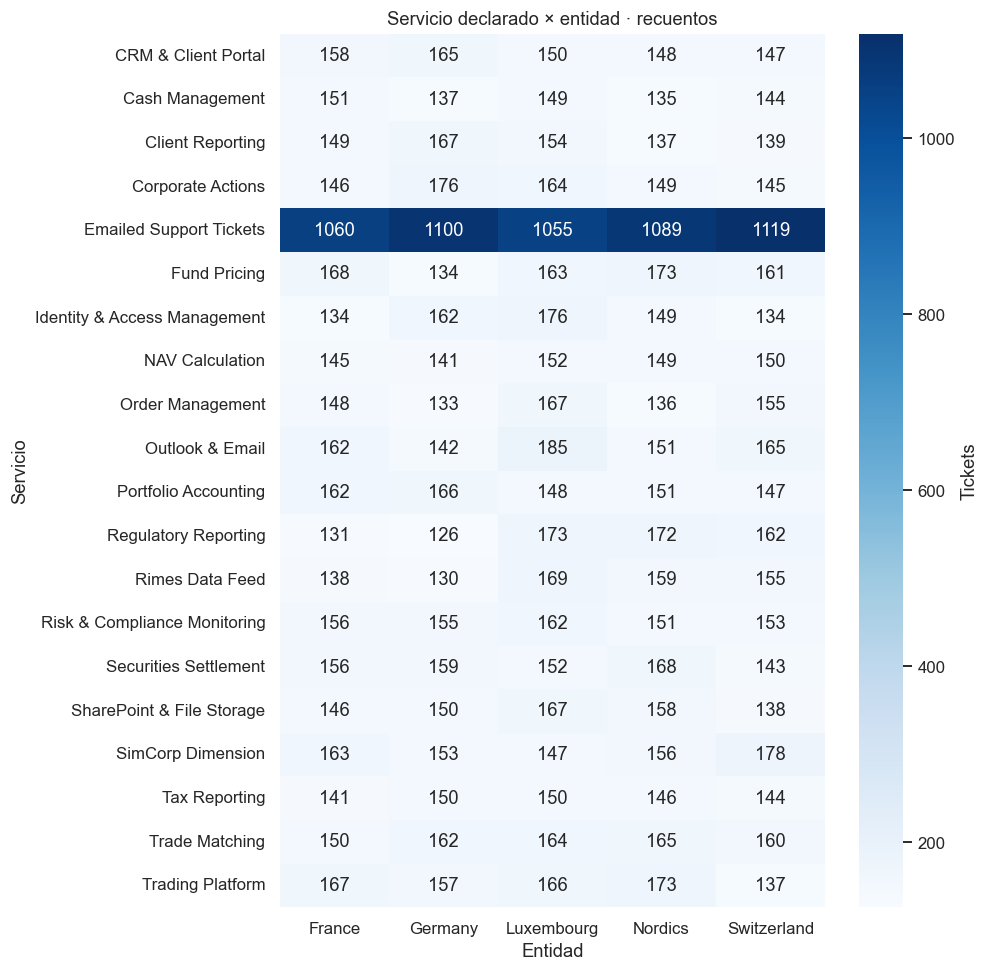

In [15]:
mostrar_tabla("frecuencia_equipos", frecuencia(equipos.iloc[:, 1], denominador=N))
for campo in ["Assignee", "Reporter"]:
    print(f"{campo}: se muestran los {TOP_N} valores más frecuentes; la exportación contiene todos.")
    mostrar_tabla("frecuencia_" + campo.lower(), frecuencia(df[campo]), limite=TOP_N)

df["dominio_reporter"] = df["Reporter"].str.extract(r"@([^@\s]+)$", expand=False).str.casefold()
mostrar_tabla("dominios_reporter", frecuencia(df["dominio_reporter"]), limite=TOP_N)

mask_rutas = df["Affected Business or IT Services"].map(len).eq(1) & df["Service Team(s)"].map(len).eq(1)
rutas = pd.DataFrame({
    "servicio": df.loc[mask_rutas, "Affected Business or IT Services"].str[0],
    "equipo": df.loc[mask_rutas, "Service Team(s)"].str[0],
})
rutas_completas = rutas.groupby(["servicio", "equipo"]).size().rename("tickets").reset_index()
rutas_completas["pct_del_servicio"] = 100 * rutas_completas["tickets"] / rutas_completas.groupby("servicio")["tickets"].transform("sum")
print(f"Cobertura de rutas con un servicio y un equipo: {mask_rutas.sum():,}/{N:,} tickets.")
mostrar_tabla("rutas_observadas", rutas_completas.sort_values(["servicio", "tickets"], ascending=[True, False]), limite=30)

mask_entidad = df["Affected Business or IT Services"].map(len).eq(1) & df["Business Entity"].map(len).eq(1)
cruce_servicio_entidad = pd.crosstab(
    df.loc[mask_entidad, "Affected Business or IT Services"].str[0],
    df.loc[mask_entidad, "Business Entity"].str[0],
)
tablas["servicio_por_entidad"] = cruce_servicio_entidad.reset_index()
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(cruce_servicio_entidad, cmap="Blues", annot=True, fmt="d", ax=ax, cbar_kws={"label": "Tickets"})
ax.set(title="Servicio declarado × entidad · recuentos", xlabel="Entidad", ylabel="Servicio")
mostrar_figura("04_servicio_entidad", fig)

## 9. Prioridad, urgencia e impacto: distribuciones de etiquetas aleatorias

El README especifica que estos tres campos son aleatorios. **Independientes no significa
uniformes**: puede haber muchos más `lowest` que `highest` sin contradecir esa advertencia.
El cruce de abajo es una tabla de frecuencias observadas; **no es la matriz de priorización**.

El reto de 20 tickets nuevos usa otra regla: prioridad derivada de urgencia e impacto.
Además, ese README habla de urgencia `Critical` y de impactos con descripciones de negocio,
mientras que aquí las etiquetas son `highest`, `high`, `medium`, `low`, `lowest`.
No inventamos una equivalencia entre ambos esquemas ni contamos sus discrepancias como errores.

,valor,tickets,pct_tickets
0,highest,384,1.92
1,high,1629,8.14
2,medium,1880,9.40
3,low,6070,30.35
4,lowest,10037,50.19


,valor,tickets,pct_tickets
0,highest,379,1.90
1,high,1618,8.09
2,medium,2008,10.04
3,low,5979,29.89
4,lowest,10016,50.08


,valor,tickets,pct_tickets
0,highest,376,1.88
1,high,1636,8.18
2,medium,1962,9.81
3,low,5962,29.81
4,lowest,10064,50.32


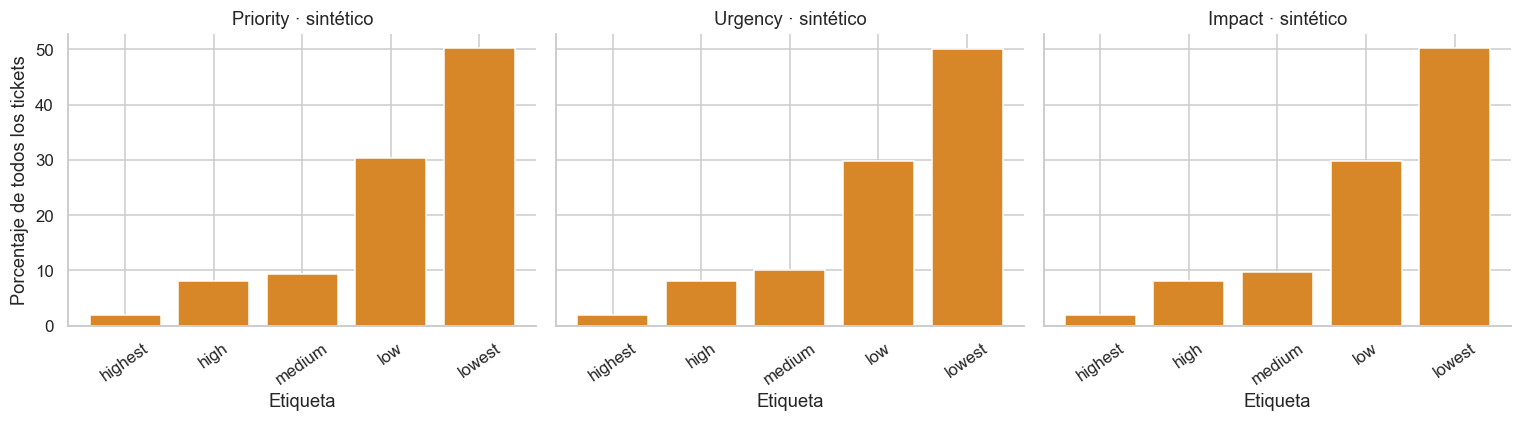

Impact,Urgency,highest,high,medium,low,lowest
0,highest,10,21,45,118,185
1,high,35,127,150,478,828
2,medium,44,157,188,642,977
3,low,110,503,588,1803,2975
4,lowest,177,828,991,2921,5099


In [16]:
ORDEN_NIVELES = ["highest", "high", "medium", "low", "lowest"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, campo in zip(axes, ["Priority", "Urgency", "Impact"]):
    tabla = frecuencia(df[campo], ORDEN_NIVELES)
    mostrar_tabla("frecuencia_" + campo.lower(), tabla)
    ax.bar(tabla["valor"], tabla["pct_tickets"], color=NARANJA)
    ax.set(title=campo + " · sintético", xlabel="Etiqueta")
    ax.tick_params(axis="x", rotation=35)
axes[0].set_ylabel("Porcentaje de todos los tickets")
mostrar_figura("05_etiquetas_aleatorias", fig)

cruce_urgencia_impacto = pd.crosstab(df["Urgency"], df["Impact"]).reindex(
    index=ORDEN_NIVELES, columns=ORDEN_NIVELES, fill_value=0
)
mostrar_tabla("urgencia_por_impacto", cruce_urgencia_impacto.reset_index())

### 10. Comprobar las fechas y su relación con el cierre

Estas reglas detectan casos que merecen revisión; no sustituyen la definición del flujo
de Jira. Los valores nulos esperables se separan de las fechas informadas que no se pueden leer.
Un ticket cancelado o no reproducible puede estar cerrado y tener fecha de resolución.

In [18]:
creacion_invalida = df["Created date"].notna() & df["created_at"].isna()
resolucion_invalida = df["Resolution date"].notna() & df["resolved_at"].isna()
reglas = {
    "Creación informada con formato no reconocido": creacion_invalida,
    "Cierre informado con formato no reconocido": resolucion_invalida,
    "Fecha de creación ausente": df["Created date"].isna(),
    "Cierre anterior a creación": df["dias_hasta_cierre"].lt(0),
    "Status done sin Resolution": df["cerrado"] & df["Resolution"].isna(),
    "Status done sin fecha de cierre válida": df["cerrado"] & df["resolved_at"].isna(),
    "Status distinto de done con Resolution": ~df["cerrado"] & df["Resolution"].notna(),
    "Status distinto de done con fecha de cierre": ~df["cerrado"] & df["resolved_at"].notna(),
}
control_fechas = pd.DataFrame([
    {"comprobacion": nombre, "tickets": int(mask.sum()), "pct_tickets": 100 * mask.sum() / N}
    for nombre, mask in reglas.items()
])
mostrar_tabla("control_fechas_y_estado", control_fechas)
ids_revision = pd.Series(False, index=df.index)
for mask in reglas.values():
    ids_revision |= mask.fillna(False)
tablas["filas_revisar_fechas"] = df.loc[ids_revision, ["analysis_row_id", "Status", "Resolution", "Created date", "Resolution date"]]

cruce_estado_resolucion = pd.crosstab(df["Status"].fillna("(sin dato)"), df["Resolution"].fillna("(sin resolución)"))
mostrar_tabla("estado_por_resolucion", cruce_estado_resolucion.reset_index())
mostrar_tabla("frecuencia_resolution", frecuencia(df["Resolution"]))
print("Rango de creación:", df["created_at"].min(), "→", df["created_at"].max())
print("Rango de cierre registrado:", df["resolved_at"].min(), "→", df["resolved_at"].max())
print("Tickets sin resolución:", df["Resolution"].isna().sum())

,comprobacion,tickets,pct_tickets
0,Creación informada con formato no reconocido,0,0.00
1,Cierre informado con formato no reconocido,0,0.00
2,Fecha de creación ausente,0,0.00
3,Cierre anterior a creación,0,0.00
4,Status done sin Resolution,0,0.00
5,Status done sin fecha de cierre válida,0,0.00
6,Status distinto de done con Resolution,0,0.00
7,Status distinto de done con fecha de cierre,0,0.00


Resolution,Status,(sin resolución),cancelled,cannot reproduce,clarification,done
0,done,0,4168,4322,4243,4236
1,in progress,2064,0,0,0,0
2,open,967,0,0,0,0


,valor,tickets,pct_tickets
0,cannot reproduce,4322,21.61
1,clarification,4243,21.21
2,done,4236,21.18
3,cancelled,4168,20.84
4,(sin dato),3031,15.15


Rango de creación: 2026-01-01 00:00:00 → 2026-08-31 23:56:00
Rango de cierre registrado: 2026-01-02 18:57:00 → 2026-09-21 08:51:00
Tickets sin resolución: 3031


## 11. Distribución temporal

Se cuentan creaciones y cierres registrados por mes. Si un mes solo contiene una parte
del periodo, su volumen no es comparable directamente con un mes completo.
La fecha de extracción no está documentada: el máximo observado **no se interpreta como
fecha de corte**, y estas series no reconstruyen todo el historial de estados o reaperturas.

,mes,creados,cierres_registrados
0,2026-01,2509,1379
1,2026-02,2276,1936
2,2026-03,2551,2170
3,2026-04,2559,2125
4,2026-05,2591,2255
5,2026-06,2502,2089
6,2026-07,2479,2105
7,2026-08,2533,2171
8,2026-09,0,739


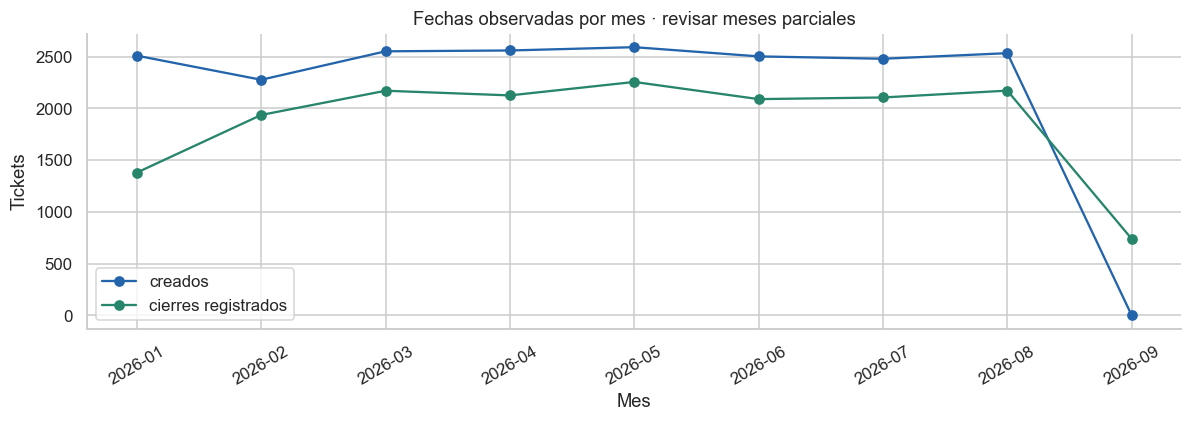

,mes_creacion,tickets,cerrados,pct_cerrados_en_la_instantanea
0,2026-01,2509,2152,85.77
1,2026-02,2276,1936,85.06
2,2026-03,2551,2140,83.89
3,2026-04,2559,2193,85.70
4,2026-05,2591,2176,83.98
5,2026-06,2502,2122,84.81
6,2026-07,2479,2110,85.11
7,2026-08,2533,2140,84.48


In [19]:
serie_creados = df["created_at"].dropna().dt.to_period("M").value_counts().sort_index()
serie_cerrados = df.loc[df["cerrado"], "resolved_at"].dropna().dt.to_period("M").value_counts().sort_index()
volumen_mensual = pd.concat([serie_creados.rename("creados"), serie_cerrados.rename("cierres_registrados")], axis=1).fillna(0).astype(int).sort_index()
volumen_mensual.index.name = "mes"
tabla_meses = volumen_mensual.reset_index()
tabla_meses["mes"] = tabla_meses["mes"].astype(str)
mostrar_tabla("volumen_mensual", tabla_meses)

fig, ax = plt.subplots(figsize=(11, 4))
for campo, color in [("creados", AZUL), ("cierres_registrados", VERDE)]:
    ax.plot(tabla_meses["mes"], tabla_meses[campo], marker="o", label=campo.replace("_", " "), color=color)
ax.set(title="Fechas observadas por mes · revisar meses parciales", xlabel="Mes", ylabel="Tickets")
ax.tick_params(axis="x", rotation=30)
ax.legend()
mostrar_figura("06_volumen_mensual", fig)

cohortes = df.dropna(subset=["created_at"]).assign(mes_creacion=lambda x: x["created_at"].dt.to_period("M").astype(str))
cohortes = cohortes.groupby("mes_creacion").agg(tickets=("analysis_row_id", "size"), cerrados=("cerrado", "sum"))
cohortes["pct_cerrados_en_la_instantanea"] = 100 * cohortes["cerrados"] / cohortes["tickets"]
mostrar_tabla("cohortes_creacion", cohortes.reset_index())

## 12. Tiempo natural hasta el cierre

Se calcula `(Resolution date − Created date)` solo en tickets con `Status = done`, ambas
fechas válidas e intervalo no negativo. Se incluyen todos los resultados de cierre, que
se muestran también por separado. Los tickets abiertos se excluyen **sin convertir su
tiempo en cero**; por ello el resumen de cerrados puede tener sesgo de selección.

La mediana (P50) divide los intervalos observados en dos mitades. El P90 es el valor por
debajo del cual queda aproximadamente el 90% de ellos. Son **días de calendario de datos
sintéticos**, no SLA ni pruebas del rendimiento real de Swiss Life o del futuro agente.

,estadistico,dias_salvo_count
0,count,"16,969.00"
1,mean,10.94
2,std,5.77
3,min,1.00
4,25%,5.97
5,50%,10.88
6,75%,15.94
7,90%,18.98
8,95%,19.97
9,max,21.00


Tickets incluidos: 16,969/20,000; excluidos: 3,031.


,Resolution,tickets,media_dias,mediana_dias,p90_dias
1,cannot reproduce,4322,10.82,10.76,18.86
2,clarification,4243,10.97,10.97,19.02
3,done,4236,11.10,11.07,19.19
0,cancelled,4168,10.87,10.81,18.83


,Work type,tickets,media_dias,mediana_dias,p90_dias
0,Incident,13552,10.99,10.96,19.00
1,Service Request,3417,10.75,10.60,18.87


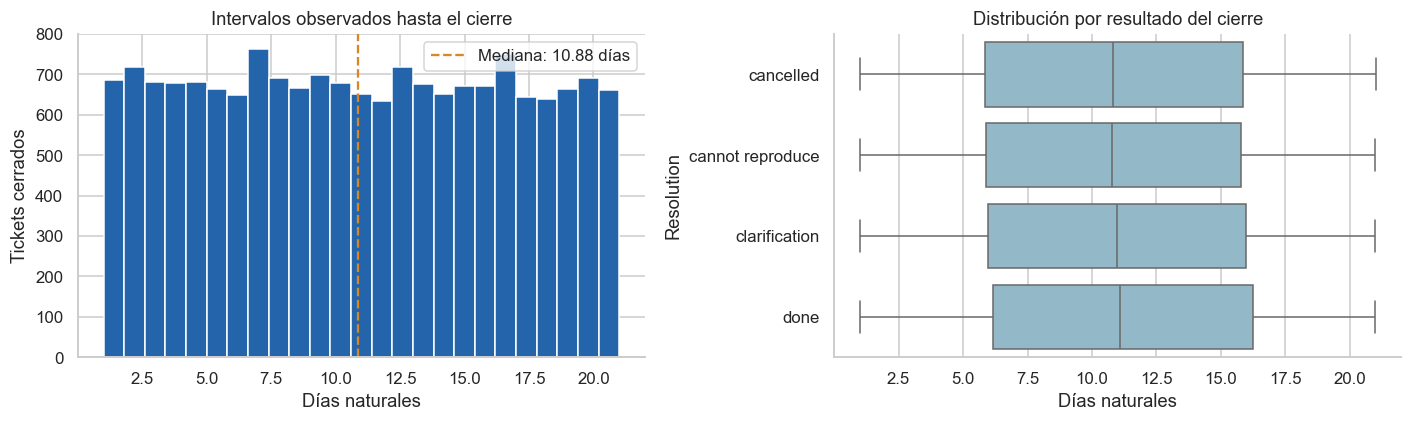

In [20]:
mask_tiempos = df["cerrado"] & df["created_at"].notna() & df["resolved_at"].notna() & df["dias_hasta_cierre"].ge(0)
cerrados_validos = df.loc[mask_tiempos].copy()
tiempos = cerrados_validos["dias_hasta_cierre"]
estadisticas_tiempo = tiempos.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).rename_axis("estadistico").reset_index(name="dias_salvo_count")
mostrar_tabla("tiempo_hasta_cierre_descriptivos", estadisticas_tiempo)
print(f"Tickets incluidos: {len(cerrados_validos):,}/{N:,}; excluidos: {N - len(cerrados_validos):,}.")

def resumen_tiempos(campo):
    return cerrados_validos.groupby(campo, dropna=False)["dias_hasta_cierre"].agg(
        tickets="size", media_dias="mean", mediana_dias="median", p90_dias=lambda s: s.quantile(0.90)
    ).reset_index().sort_values("tickets", ascending=False)

for campo, nombre in [("Resolution", "resolucion"), ("Work type", "tipo")]:
    mostrar_tabla("tiempos_por_" + nombre, resumen_tiempos(campo))

if len(cerrados_validos):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(tiempos, bins=25, color=AZUL, edgecolor="white")
    axes[0].axvline(tiempos.median(), color=NARANJA, linestyle="--", label=f"Mediana: {tiempos.median():.2f} días")
    axes[0].set(title="Intervalos observados hasta el cierre", xlabel="Días naturales", ylabel="Tickets cerrados")
    axes[0].legend()
    orden_resoluciones = sorted(cerrados_validos["Resolution"].dropna().unique())
    sns.boxplot(data=cerrados_validos, y="Resolution", x="dias_hasta_cierre", order=orden_resoluciones, color="#8ABBD1", ax=axes[1])
    axes[1].set(title="Distribución por resultado del cierre", xlabel="Días naturales", ylabel="Resolution")
    mostrar_figura("07_tiempo_hasta_cierre", fig)

## 13. Duplicados y repetición de plantillas

Un **duplicado completo** repite todos los campos del objeto. Una **plantilla textual
repetida** comparte título y descripción tras normalizar mayúsculas y espacios, aunque
cambien fechas, personas, estado o comentarios. No se borran registros automáticamente.

Si se entrena o evalúa un modelo después, separar aleatoriamente filas muy parecidas puede
producir fuga de información. Una alternativa inicial es separar por grupo de plantilla y
auditar también similitud semántica y disponibilidad temporal de la información.

In [22]:
canonicos = pd.Series([json.dumps(r, sort_keys=True, ensure_ascii=False, separators=(",", ":")) for r in registros])
duplicados_completos = int(canonicos.duplicated().sum())

def normalizar_texto(valor):
    return re.sub(r"\s+", " ", str(valor).casefold()).strip() if pd.notna(valor) else ""

pares_normalizados = [
    json.dumps([normalizar_texto(s), normalizar_texto(d)], ensure_ascii=False)
    for s, d in zip(df["Summary"], df["Description"])
]
df["plantilla_texto_id"] = [hashlib.sha256(p.encode("utf-8")).hexdigest() for p in pares_normalizados]
conteo_plantillas = df["plantilla_texto_id"].value_counts()
plantillas = df.groupby("plantilla_texto_id", sort=False).agg(
    tickets=("analysis_row_id", "size"), titulo_ejemplo=("Summary", "first"), descripcion_ejemplo=("Description", "first")
).reset_index().sort_values("tickets", ascending=False)

repeticion = pd.DataFrame([
    ("Duplicados completos adicionales al primero", duplicados_completos),
    ("Pares de título y descripción sin normalizar", len(raw[["Summary", "Description"]].drop_duplicates())),
    ("Plantillas normalizadas distintas", len(conteo_plantillas)),
    ("Filas adicionales al primer ejemplo de cada plantilla", N - len(conteo_plantillas)),
    ("Tickets en plantillas que aparecen más de una vez", int(conteo_plantillas[conteo_plantillas.gt(1)].sum())),
], columns=["metrica", "tickets_o_plantillas"])
mostrar_tabla("repeticion_textual", repeticion)
mostrar_tabla("plantillas_textuales", plantillas, limite=TOP_N)

,metrica,tickets_o_plantillas
0,Duplicados completos adicionales al primero,0
1,Pares de título y descripción sin normalizar,173
2,Plantillas normalizadas distintas,173
3,Filas adicionales al primer ejemplo de cada plantilla,19827
4,Tickets en plantillas que aparecen más de una vez,20000


,plantilla_texto_id,tickets,titulo_ejemplo,descripcion_ejemplo
98,834554e1f51ebf2240cdb264b2f40d60f69eb9f98f5b616eb6d731ea6beb88f9,4212,External email warning received for Emailed Support Tickets,A third party sent a warning regarding Emailed Support Tickets. The email references a delayed f...
11,a9482fe8b5f10fd9a705cdfbbe1c5e8a33a12fa9e4a58977293094e7a6ab5b76,1211,Email notification received for Emailed Support Tickets,An external party sent an email warning related to Emailed Support Tickets. The message referenc...
145,adc741c8ae13b36fc79b76865cd77b5ff03609e50295166a9717ec81b9f058de,434,Automated alert triggered for SimCorp Dimension,SimCorp Dimension generated an automated monitoring alert indicating an operational problem. The...
97,f42edf96c22c5349b8b3e1327a0cd774e485eebd680fddc467704b0a9a7fd64c,420,Automated alert triggered for Trading Platform,Trading Platform generated an automated monitoring alert indicating an operational problem. The ...
132,894c52f2bb3f80e16081032ea0be052455382909c471c649a13b4d7f951700cc,414,Automated alert triggered for Outlook & Email,Outlook & Email generated an automated monitoring alert indicating an operational problem. The l...
120,5613baab4ce007353a6e5ba3bb7b259a453686bfdf3a507723f706d60b8fc3b7,409,Automated alert triggered for Portfolio Accounting,Portfolio Accounting generated an automated monitoring alert indicating an operational problem. ...
133,655eb92b8bcb0f2a28e1ebd6d3582df6e9af21c8231c15567ba39f83ca7bd852,408,Automated alert triggered for Fund Pricing,Fund Pricing generated an automated monitoring alert indicating an operational problem. The log ...
108,d5a956a6deece75de42edee88df2437203d518cbec89b0131965254e25d3218f,407,Automated alert triggered for Trade Matching,Trade Matching generated an automated monitoring alert indicating an operational problem. The lo...
115,d8bf08a8b90c4cc751d892fa325115268bf515e0e5980ef71ad02a15b8bcc184,401,Automated alert triggered for Rimes Data Feed,Rimes Data Feed generated an automated monitoring alert indicating an operational problem. The l...
107,4d18d735ab769e0a7c2914717f61d53c76cc88e800e0838bafeae53599f548d0,393,Automated alert triggered for SharePoint & File Storage,SharePoint & File Storage generated an automated monitoring alert indicating an operational prob...


## 14. Descripción y comentarios como material de conocimiento

Se calcula longitud de texto, número de comentarios y frecuencia de frases. El prefijo
de autor se separa solo si parece una dirección de correo seguida de `:`. Los comentarios
no incluyen fechas individuales en este archivo; no se puede medir primera respuesta ni
saber cuáles estaban disponibles al crear cada ticket.

Las señales `Problem fixed.`, comentario de hasta 8 palabras y prefijo `Resolution:` son
**reglas literales de exploración**, no una evaluación automática de la calidad de una solución.
Se cuentan comentarios y tickets afectados por separado para evitar confundir denominadores.

,estadistico,summary_chars,description_chars,description_words,n_comments
0,count,"20,000.00","20,000.00","20,000.00","20,000.00"
1,mean,51.58,271.15,40.21,2.64
2,std,7.45,21.65,3.97,1.17
3,min,33.00,204.00,31.00,1.00
4,25%,45.00,271.00,37.00,2.00
5,50%,51.00,276.00,38.00,3.00
6,75%,59.00,279.00,44.00,4.00
7,max,76.00,315.00,47.00,5.00


,valor,tickets,pct_tickets
0,1,4115,20.57
1,2,5232,26.16
2,3,5422,27.11
3,4,4155,20.77
4,5,1076,5.38


,texto,comentarios,pct_comentarios
0,problem fixed.,5851,11.07
1,initial triage assigned to service desk and reviewed against the service catalogue.,3850,7.29
2,we validated the issue against emailed support tickets and checked whether it matched the expect...,3850,7.29
3,initial triage assigned to enterprise applications and reviewed against the service catalogue.,2231,4.22
4,impact assessment confirmed the issue affected the operational workflow for emailed support tick...,2052,3.88
5,initial triage assigned to investment operations and reviewed against the service catalogue.,1696,3.21
6,initial triage assigned to securities operations and reviewed against the service catalogue.,1110,2.10
7,initial triage assigned to valuation & pricing and reviewed against the service catalogue.,1080,2.04
8,initial triage assigned to client services and reviewed against the service catalogue.,1079,2.04
9,initial triage assigned to risk & controls and reviewed against the service catalogue.,1076,2.04


,senal,comentarios,pct_comentarios,tickets_con_al_menos_uno,pct_todos_los_tickets
0,problem_fixed_literal,5851,11.07,5851,29.25
1,breve_8_palabras,10674,20.20,10674,53.37
2,marcador_resolucion,10637,20.13,8995,44.98


Comentarios totales: 52845 | Cuerpos distintos: 79


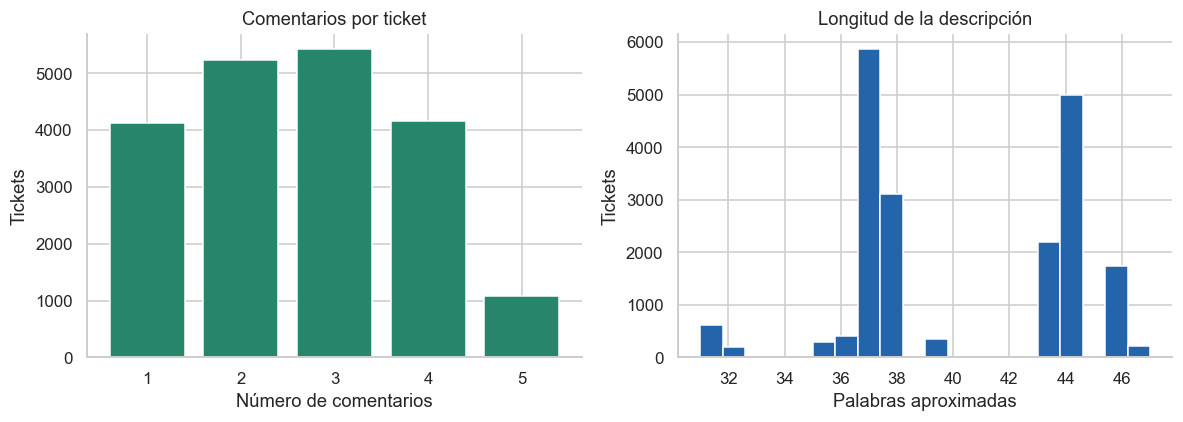

In [23]:
for campo, prefijo in [("Summary", "summary"), ("Description", "description")]:
    df[prefijo + "_chars"] = df[campo].fillna("").str.len()
    df[prefijo + "_words"] = df[campo].fillna("").str.findall(r"\b\w+\b").str.len()

comentarios = df[["analysis_row_id", "All Comments"]].explode("All Comments").dropna(subset=["All Comments"]).rename(columns={"All Comments": "comentario_original"})
comentarios = comentarios.reset_index(drop=True)
comentarios["orden_en_lista"] = comentarios.groupby("analysis_row_id").cumcount() + 1

def separar_autor(texto):
    primero, separador, resto = texto.partition(":")
    if separador and re.fullmatch(r"[^\s@:]+@[^\s@:]+", primero.strip()):
        return primero.strip(), resto.strip()
    return pd.NA, texto.strip()

comentarios[["autor", "texto"]] = pd.DataFrame(
    comentarios["comentario_original"].map(separar_autor).tolist(), index=comentarios.index
)
comentarios["palabras"] = comentarios["texto"].str.findall(r"\b\w+\b").str.len()
comentarios["texto_normalizado"] = comentarios["texto"].map(normalizar_texto)
comentarios["problem_fixed_literal"] = comentarios["texto_normalizado"].eq("problem fixed.")
comentarios["breve_8_palabras"] = comentarios["palabras"].le(8)
comentarios["marcador_resolucion"] = comentarios["texto"].str.contains(r"^resolution(?: recorded)?\s*:", case=False, regex=True)

mostrar_tabla("descriptivos_texto_y_comentarios", df[["summary_chars", "description_chars", "description_words", "n_comments"]].describe().rename_axis("estadistico").reset_index())
mostrar_tabla("distribucion_numero_comentarios", frecuencia(df["n_comments"], orden=[str(x) for x in sorted(df["n_comments"].unique())]))
frases = comentarios["texto_normalizado"].value_counts().rename_axis("texto").reset_index(name="comentarios")
frases["pct_comentarios"] = 100 * frases["comentarios"] / len(comentarios)
mostrar_tabla("frases_comentarios", frases, limite=TOP_N)

senales = []
for campo in ["problem_fixed_literal", "breve_8_palabras", "marcador_resolucion"]:
    mask = comentarios[campo]
    n_tickets = comentarios.loc[mask, "analysis_row_id"].nunique()
    senales.append({"senal": campo, "comentarios": int(mask.sum()),
                    "pct_comentarios": 100 * mask.mean(), "tickets_con_al_menos_uno": n_tickets,
                    "pct_todos_los_tickets": 100 * n_tickets / N})
mostrar_tabla("senales_literales_comentarios", pd.DataFrame(senales))

print("Comentarios totales:", len(comentarios), "| Cuerpos distintos:", comentarios["texto_normalizado"].nunique())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
conteos_comentarios = df["n_comments"].value_counts().sort_index()
axes[0].bar(conteos_comentarios.index, conteos_comentarios, color=VERDE)
axes[0].set(title="Comentarios por ticket", xlabel="Número de comentarios", ylabel="Tickets")
axes[0].set_xticks(conteos_comentarios.index)
axes[1].hist(df["description_words"], bins=20, color=AZUL, edgecolor="white")
axes[1].set(title="Longitud de la descripción", xlabel="Palabras aproximadas", ylabel="Tickets")
mostrar_figura("08_texto_y_comentarios", fig)

## 15. Señales para revisar la etiqueta del servicio

Se buscan nombres literales del catálogo únicamente en `Summary` y `Description`.
Cuando aparece un solo servicio y no coincide con el campo declarado, marcamos una
**discrepancia candidata**. No es una clasificación semántica ni un porcentaje de error:
un texto puede mencionar un servicio sin que sea el afectado, omitirlo o usar un alias.
No se sobrescribe ningún campo ni se usa el comentario de cierre para inferir la entrada original.

In [24]:
patrones_servicios = {
    nombre: re.compile(r"(?<!\w)" + re.escape(nombre) + r"(?!\w)", flags=re.IGNORECASE)
    for nombre in CATALOGO
}
texto_entrada = df["Summary"].fillna("") + " " + df["Description"].fillna("")
# Cacheamos textos repetidos, pero asignamos el resultado a todas las filas.
menciones_por_texto = {texto: [nombre for nombre, patron in patrones_servicios.items() if patron.search(texto)] for texto in texto_entrada.unique()}
df["servicios_mencionados_literalmente"] = texto_entrada.map(menciones_por_texto)
df["discrepancia_servicio_candidata"] = [
    len(menciones) == 1 and len(declarados) == 1 and menciones[0].casefold() != declarados[0].casefold()
    for menciones, declarados in zip(df["servicios_mencionados_literalmente"], df["Affected Business or IT Services"])
]
mask_mencion_unica = df["servicios_mencionados_literalmente"].map(len).eq(1) & df["Affected Business or IT Services"].map(len).eq(1)
n_comparables = int(mask_mencion_unica.sum())
n_discrepancias = int(df["discrepancia_servicio_candidata"].sum())
mostrar_tabla("resumen_menciones_servicio", pd.DataFrame([
    ("Tickets con mención única y servicio declarado único", n_comparables),
    ("Discrepancias candidatas", n_discrepancias),
    ("Tickets sin mención literal de un servicio del catálogo", int(df["servicios_mencionados_literalmente"].map(len).eq(0).sum())),
    ("Tickets con varias menciones literales", int(df["servicios_mencionados_literalmente"].map(len).gt(1).sum())),
], columns=["metrica", "tickets"]))
if n_comparables:
    print(f"Discrepancias candidatas entre comparables: {100 * n_discrepancias / n_comparables:.2f}% ({n_discrepancias:,}/{n_comparables:,}).")

revision_servicios = df.loc[df["discrepancia_servicio_candidata"], [
    "analysis_row_id", "Summary", "Affected Business or IT Services", "servicios_mencionados_literalmente"
]]
mostrar_tabla("servicios_candidatos_revision", revision_servicios, limite=TOP_N)

,metrica,tickets
0,Tickets con mención única y servicio declarado único,20000
1,Discrepancias candidatas,0
2,Tickets sin mención literal de un servicio del catálogo,0
3,Tickets con varias menciones literales,0


Discrepancias candidatas entre comparables: 0.00% (0/20,000).


,analysis_row_id,Summary,Affected Business or IT Services,servicios_mencionados_literalmente


## 16. Conclusiones calculadas a partir del archivo

La siguiente celda genera los hallazgos con las cifras de esta ejecución. Si cambias el
JSON y mantienes el mismo esquema, las cantidades se recalculan.

In [25]:
n_cerrados = int(df["cerrado"].sum())
n_resultado_done = int(df["Resolution"].eq("done").sum())
n_genericos = int(df["Affected Business or IT Services"].map(lambda x: "Emailed Support Tickets" in x).sum())
n_fixed = int(comentarios["problem_fixed_literal"].sum())
n_plantillas = int(df["plantilla_texto_id"].nunique())
notas = [
    f"**Cobertura:** {N:,} tickets, {len(raw.columns)} campos originales y {len(comentarios):,} comentarios, sin muestreo.",
    f"**Tipo:** {int(df['Work type'].eq('Incident').sum()):,} incidentes y {int(df['Work type'].eq('Service Request').sum()):,} solicitudes de servicio.",
    f"**Estado:** {n_cerrados:,} tickets están en estado `done` ({100*n_cerrados/N:.2f}%). Solo {n_resultado_done:,} tienen además resultado de resolución `done` ({100*n_resultado_done/N:.2f}% del total).",
    f"**Completitud:** {int(df['Resolution'].isna().sum()):,} tickets carecen de resolución y {int(df['resolved_at'].isna().sum()):,} de fecha de cierre válida. Consultar el cruce con el estado antes de considerarlos errores.",
    f"**Repetición:** {duplicados_completos:,} duplicados completos adicionales al primero y {n_plantillas:,} plantillas de título + descripción normalizados. Evitar una evaluación basada en mezclar estas plantillas entre entrenamiento y prueba.",
    f"**Servicio genérico:** {n_genericos:,} tickets declaran `Emailed Support Tickets` ({100*n_genericos/N:.2f}%). La comprobación literal detecta {n_discrepancias:,} discrepancias candidatas que requieren revisión.",
    f"**Comentarios:** la frase exacta `Problem fixed.` aparece {n_fixed:,} veces ({100*n_fixed/len(comentarios):.2f}% de los comentarios); por sí sola no explica cómo resolver un caso similar.",
    "**Prioridad:** las distribuciones de Priority, Urgency e Impact describen etiquetas aleatorias; no sirven como referencia fiable para entrenar ni puntuar la priorización real.",
]
if len(tiempos):
    notas.insert(4, f"**Tiempo hasta el cierre:** mediana {tiempos.median():.2f} días y P90 {tiempos.quantile(.9):.2f} días, sobre {len(tiempos):,} tickets cerrados con fechas válidas. Son intervalos sintéticos de calendario, no un SLA.")
display(Markdown("\n\n".join("- " + nota for nota in notas)))

- **Cobertura:** 20,000 tickets, 16 campos originales y 52,845 comentarios, sin muestreo.

- **Tipo:** 16,000 incidentes y 4,000 solicitudes de servicio.

- **Estado:** 16,969 tickets están en estado `done` (84.84%). Solo 4,236 tienen además resultado de resolución `done` (21.18% del total).

- **Completitud:** 3,031 tickets carecen de resolución y 3,031 de fecha de cierre válida. Consultar el cruce con el estado antes de considerarlos errores.

- **Tiempo hasta el cierre:** mediana 10.88 días y P90 18.98 días, sobre 16,969 tickets cerrados con fechas válidas. Son intervalos sintéticos de calendario, no un SLA.

- **Repetición:** 0 duplicados completos adicionales al primero y 173 plantillas de título + descripción normalizados. Evitar una evaluación basada en mezclar estas plantillas entre entrenamiento y prueba.

- **Servicio genérico:** 5,423 tickets declaran `Emailed Support Tickets` (27.11%). La comprobación literal detecta 0 discrepancias candidatas que requieren revisión.

- **Comentarios:** la frase exacta `Problem fixed.` aparece 5,851 veces (11.07% de los comentarios); por sí sola no explica cómo resolver un caso similar.

- **Prioridad:** las distribuciones de Priority, Urgency e Impact describen etiquetas aleatorias; no sirven como referencia fiable para entrenar ni puntuar la priorización real.

## 17. Cómo aprovecharlo en el agente del hackathon

| Uso | Campos o resultados útiles | Criterio de interpretación |
|---|---|---|
| Entender un ticket nuevo | Summary, Description, Business Entity, servicio declarado | El servicio declarado puede ser genérico o erróneo. |
| Recuperar conocimiento histórico (RAG) | Textos similares, comentarios y resultado de cierre | Revisar que el caso aporta pasos de solución y no solo “Problem fixed.”. |
| Proponer equipo y responsable | Service Team(s), Assignee y rutas observadas | Validar con el catálogo y responsables de dominio; frecuencia no equivale a idoneidad. |
| Proponer prioridad | Texto y reglas del README para el reto | Crear etiquetas revisadas; no aprender las prioridades aleatorias de este archivo. |
| Evaluar | Grupos de plantillas y un conjunto de evaluación revisado | Evitar duplicados y usar únicamente información disponible en el momento de la predicción. |
| Medir el futuro agente | Eventos de sugerencia, aprobación, edición, rechazo y tiempos | Estos eventos no están en el JSON: no se puede calcular aceptación del borrador o ahorro de tiempo aquí. |

Para clasificar al entrar el ticket, `Resolution`, `Resolution date`, estado final y
comentarios posteriores al ingreso serían **información futura**. Pueden servir como
material histórico de RAG para otros casos, pero no deben filtrarse como entrada del
mismo ticket en una evaluación. El analista debe revisar las recomendaciones.

**Limitaciones adicionales:** faltan claves Jira estables, historial de estados, fechas
de cada comentario, SLA, horas laborales y una fecha de extracción documentada. No se
pueden calcular de forma fiable primera respuesta, reaperturas, esfuerzo, incumplimiento
de SLA, evolución histórica exacta del backlog ni causalidad entre variables.

## 18. Exportar resultados y comprobar la cobertura

Se guardan tablas CSV en UTF-8 (compatibles con Excel), gráficos PNG y un manifiesto con
el hash del archivo, las versiones y las limitaciones. Las tablas de frecuencias y
plantillas se exportan **completas**, aunque antes se mostraran solo 10 filas.

Si activas `EXPORTAR_DATOS_DETALLADOS = True`, también se generan `tickets_preparados.csv`
y `comentarios_separados.csv`. Las listas se escriben como JSON dentro de cada celda CSV.
Los CSV son resultados de análisis; no constituyen etiquetas validadas ni un modelo entrenado.

In [28]:
# Comprobaciones de integridad: no se han perdido ni multiplicado tickets.
assert len(df) == len(registros) == N
assert df["analysis_row_id"].is_unique
assert int(plantillas["tickets"].sum()) == N
assert len(comentarios) == int(df["n_comments"].sum())
assert len(cerrados_validos) == int(mask_tiempos.sum())
assert int(tablas["frecuencia_status"]["tickets"].sum()) == N
assert int(volumen_mensual["creados"].sum()) == int(df["created_at"].notna().sum())

def serializar_listas(tabla):
    salida = tabla.copy()
    for c in salida.columns:
        if any(isinstance(x, (list, dict)) for x in salida[c]):
            salida[c] = salida[c].map(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict)) else x)
    return salida

manifiesto = {
    "archivo_entrada": DATA_FILE.name,
    "sha256_entrada": sha256_entrada,
    "fecha_ejecucion_utc": datetime.now(timezone.utc).isoformat(),
    "tickets": N,
    "campos_originales": raw.columns.tolist(),
    "comentarios": len(comentarios),
    "tickets_cerrados": n_cerrados,
    "plantillas_textuales_normalizadas": n_plantillas,
    "duplicados_completos_adicionales": duplicados_completos,
    "python": platform.python_version(),
    "paquetes": versiones,
    "zona_horaria_datos": "No especificada; fechas naive, sin conversión a UTC",
    "datos_sinteticos": True,
    "se_utilizan_todos_los_registros": True,
    "entrena_modelos": False,
    "fuentes": [DATA_FILE.name, "README.md adjunto al challenge"],
    "limitaciones": [
        "Priority, Urgency e Impact son aleatorios según el README.",
        "Servicio declarado y rutas históricas no son verdad de referencia.",
        "Tiempo hasta cierre en días naturales, solo entre cerrados con fechas válidas.",
        "Sin claves Jira, fecha de extracción, SLA, historial o fechas de comentarios.",
        "El archivo separado del reto de 20 tickets no se ha incluido.",
    ],
}
if EXPORTAR:
    (OUTPUT_DIR / "tablas").mkdir(parents=True, exist_ok=True)
    for nombre, tabla in tablas.items():
        serializar_listas(tabla).to_csv(OUTPUT_DIR / "tablas" / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    if EXPORTAR_DATOS_DETALLADOS:
        serializar_listas(df).to_csv(OUTPUT_DIR / "tickets_preparados.csv", index=False, encoding="utf-8-sig")
        comentarios.to_csv(OUTPUT_DIR / "comentarios_separados.csv", index=False, encoding="utf-8-sig")
    (OUTPUT_DIR / "manifiesto.json").write_text(json.dumps(manifiesto, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Guardadas {len(tablas)} tablas completas y 8 gráficos en: {OUTPUT_DIR}")
else:
    print("Exportación desactivada. Los resultados se conservan en las salidas del notebook.")
print(f"Verificación completada: {N:,} tickets y {len(comentarios):,} comentarios procesados.")

Guardadas 37 tablas completas y 8 gráficos en: resultados_tickets
Verificación completada: 20,000 tickets y 52,845 comentarios procesados.
